<a href="https://colab.research.google.com/github/MDankloff/Delayed-Fairness-Project/blob/main/BAF_Base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BAF calibrated version of cloned_ltf_pop.

same pipeline: generator/ simulator/ fair_model / baseline / utils / evaluation (LR, LCF, EO, DP) --> Without PE
make 12 result grid comparing v1 and v2 to base data

same run and evaluate () workflow only the data source is BAF and the Banks ground truth bias change.

Sensitive attribute: AGE (turning the tables paper 2022)
generator (k_same/k_other) thus works same --> need to add graph_sensitivity.py


In [107]:
#Clone / mount, same as cloned_ltf_pop
import os
import sys

repo_url = "https://github.com/MDankloff/Delayed-Fairness-Project.git"
repo_dir = "/content/Delayed-Fairness-Project"

if not os.path.exists(repo_dir):
    os.system(f"git clone {repo_url} {repo_dir}")
else:
    os.system(f"git -C {repo_dir} pull origin main")

src_path = os.path.join(repo_dir, "Synthetic", "src")
assert os.path.exists(os.path.join(src_path, "generator.py")), \
    f"generator.py not found at {src_path} -- check the clone succeeded"

if src_path not in sys.path:
    sys.path.insert(0, src_path)

print("Using:", src_path)


Using: /content/Delayed-Fairness-Project/Synthetic/src


# Libraries

In [108]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import yaml
import random
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
import glob
import joblib

import generator as gen_mod #gen_multi_steps_profiles lives only here
from generator import Agent as GenAgentBase        # used for the training-data bootstrap
from simulator import Bank, Agent as SimAgentBase, run_simulation
from evaluation import compute_statistics
from fair_model import FairModel
from baselines import LR, CvxFairModel, EOFairModel
from utils import combine_tuples

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


# Load BAF data

Saved parquet files from csv

In [109]:
from google.colab import drive
drive.mount('/content/drive')
!cd '/content/drive/MyDrive/Supervision 2025-2027/Paper #4: Longterm Fairness under population dynamics/BAF'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [110]:
base_path = '/content/drive/MyDrive/Supervision 2025-2027/Paper #4: Longterm Fairness under population dynamics/BAF/parquet data'

extension = "parquet" #parquet for smaller files, csv available
data_paths = glob.glob(f"{base_path}/*.{extension}")

def read_dataset(path, ext = extension):
    if ext == "csv":
      return pd.read_csv(path)
    elif ext == "parquet":
      return pd.read_parquet(path)
    else:
      raise ValueError(f"Unsupported file extension: {ext}")

# Extract variant name from the file path (without the extension)
def get_variant(path):
    return os.path.basename(path).split(".")[0]

# Dictionary comprehension to read all CSV files into a dictionary of DataFrames
dataframes = {
    get_variant(path): read_dataset(path) for path in data_paths
}
print(f"Loaded datasets: {list(dataframes.keys())}")

datasets_paths = {
    "Base": base_path + "/Base.parquet", # sampled to best represent original dataset
    "Variant I": base_path + "/Variant I.parquet", # higher group size disparity than base - reducing the size of the minority group from approx 20 - 10% of the dataset
    "Variant II": base_path + "/Variant II.parquet", # higher prevalence disparity than base - one group has 5 x the fraud detection rate of the other while group sizes are equal
    "Variant III": base_path + "/Variant III.parquet", # better separability for one of the groups
    "Variant IV": base_path + "/Variant IV.parquet", # higher prevalence disparity in train
    "Variant V": base_path + "/Variant V.parquet", # better separability in train for one of the groups
}

Loaded datasets: ['Base', 'Variant I', 'Variant II', 'Variant III', 'Variant IV', 'Variant V']


In [111]:
#Rename datasets
base = dataframes['Base']
variant1 = dataframes['Variant I']
variant2 = dataframes['Variant II']
variant3 = dataframes['Variant III']
variant4 = dataframes['Variant IV']
variant5 = dataframes['Variant V']

#for better display
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 50)

dfs = [base, variant1, variant2, variant3, variant4, variant5]

#dataset used for comparison group size (gs) and fraud prevalence (pr)
base_df = base.copy() # majority: 77% gs, 0.9% pr minority: 23% gs, 1.8% pr
v1_df = variant1.copy() # majority: 90% gs, 1.1% pr, minority: 10% gs, 1.1% pr (higher gs disparity than base)
v2_df = variant2.copy() # majority: 50% gs, 0.4% pr, minority: 50% gs, 1.9% pr: (higher pr disparity than base)

# Explore Data

In [112]:
#print(f"v1_df: {len(v1_df):,} rows")

In [113]:
#make a simplified df containing only a few features
v1_simple = v1_df[['fraud_bool', 'customer_age', 'income','credit_risk_score', 'proposed_credit_limit']].copy()
v2_simple = v2_df[['fraud_bool', 'customer_age', 'income','credit_risk_score', 'proposed_credit_limit']].copy()
base_simple = base_df[['fraud_bool', 'customer_age', 'income','credit_risk_score', 'proposed_credit_limit']].copy()

In [114]:
# Display descriptive statistics for the 'income' column
display(base_simple['customer_age'].describe())

,customer_age
count,1000000.000000
mean,33.689080
std,12.025799
min,10.000000
25%,20.000000
50%,30.000000
75%,40.000000
max,90.000000


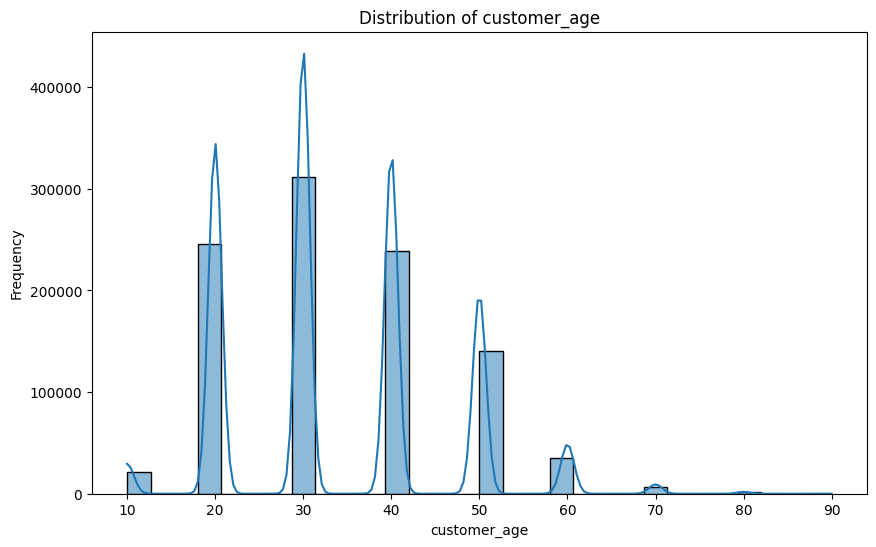

In [115]:
plt.figure(figsize=(10, 6))
sns.histplot(base_simple['customer_age'], bins=30, kde=True)
plt.title('Distribution of customer_age')
plt.xlabel('customer_age')
plt.ylabel('Frequency')
plt.show()

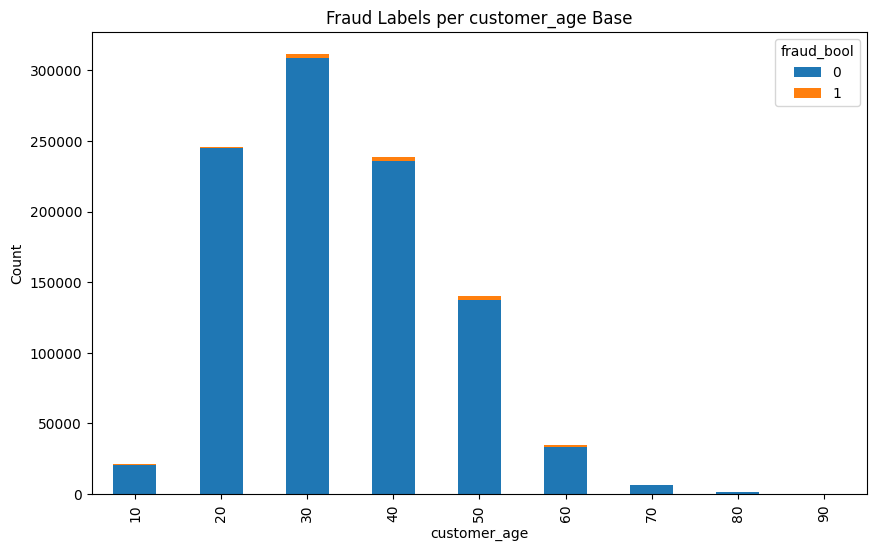

In [116]:
#fraud per customer_age
fraud_per_month = base_simple.groupby(['customer_age','fraud_bool']).size().unstack()
fraud_per_month.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Fraud Labels per customer_age Base')
plt.xlabel('customer_age')
plt.ylabel('Count')
plt.show()

In [117]:
print(base_simple.iloc[0])

fraud_bool                  0.0
customer_age               40.0
income                      0.3
credit_risk_score         163.0
proposed_credit_limit    1500.0
Name: 0, dtype: float64


In [118]:
print(base_simple['customer_age'].value_counts())
print(base_simple.groupby('customer_age')['fraud_bool'].mean())

customer_age
30    311433
20    245855
40    238712
50    140353
60     34770
10     20987
70      6517
80      1297
90        76
Name: count, dtype: int64
customer_age
10    0.003526
20    0.004901
30    0.008313
40    0.012048
50    0.019985
60    0.033046
70    0.040356
80    0.049345
90    0.052632
Name: fraud_bool, dtype: float64


In [119]:
base_simple.groupby('customer_age')['income'].mean()   # mean income by age group
# or
pd.crosstab(base_simple['customer_age'], base_simple['income'])

income,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
customer_age,,,,,,,,,
10,6359,2147,1379,1961,1171,2092,1722,1995,2161
20,51642,20781,14617,22527,14718,28382,24663,31377,37148
30,46607,21303,15954,25519,17673,35632,33592,46726,68427
40,28198,13751,10407,17294,12402,25884,26043,38445,66288
50,18051,8454,6381,10662,7464,15246,14660,21741,37694
60,5327,2342,1711,2780,1994,3829,3613,5185,7989
70,1040,470,308,513,355,775,674,966,1416
80,214,92,72,101,74,125,135,203,281
90,11,5,4,7,7,8,7,12,15


# Create demographic groups

Create groups based on AGE (Jesus et al., 2022)
paper's stated target for group size split v1 (90-10) not exactly 10 % minority with >50 but with >=50 closer (11.07%).

we define customer_age threshold at >=50 for minority

In [120]:
def add_age_group(df):
  df = df.copy()
  df['S'] = (df['customer_age'] >= 50).astype(int) # 1 = older minority
  return df

base_simple = add_age_group(base_simple)
v1_simple = add_age_group(v1_simple)
v2_simple = add_age_group(v2_simple)


In [121]:
def group_stats(df,name):
  size = df['S'].value_counts(normalize=True) * 100
  rate0 = df.loc[df['S'] == 0, 'fraud_bool'].mean() * 100
  rate1 = df.loc[df['S'] == 1, 'fraud_bool'].mean() * 100
  ratio = max(rate0, rate1) / min(rate0, rate1) if min(rate0, rate1) > 0 else float('nan')
  print(f"===={name}===")
  print(f"  Group sizes:   S=0 (Younger)={size.get(0,0):.2f}%   S=1 (Older)={size.get(1,0):.2f}%")
  print(f"  Fraud rates:   S=0={rate0:.3f}%   S=1={rate1:.3f}%   ratio={ratio:.2f}x")
  print()

group_stats(base_simple, "Base")
group_stats(v1_simple, "Variant I")
group_stats(v2_simple, "Variant II")



====Base===
  Group sizes:   S=0 (Younger)=81.70%   S=1 (Older)=18.30%
  Fraud rates:   S=0=0.825%   S=1=2.341%   ratio=2.84x

====Variant I===
  Group sizes:   S=0 (Younger)=88.93%   S=1 (Older)=11.07%
  Fraud rates:   S=0=1.089%   S=1=1.216%   ratio=1.12x

====Variant II===
  Group sizes:   S=0 (Younger)=49.42%   S=1 (Older)=50.58%
  Fraud rates:   S=0=0.364%   S=1=1.825%   ratio=5.01x



# Make Feature Matrix for each applicant

Make feature matrix X: Each applicant i has a binary protected attribute S ∈ {0, 1} (e.g., customer_age), a vector of dynamic features Xt ∈ Rd (e.g., credit risk score at time t), and a ground-truth label Y indicating whether the applicant can pay back (Yi,t =1) or default (Yi,t = −1).

In [122]:
#  Build feature matrix X a sensitive feature, 2 dynamic features and a fraud bool (S= customer_age, X1_t = credit risk score, X2_t=proposed credit limit, Y).
# Bank.params needs 4 values [w_s, w_x1, w_x2, w_intercept]

X_COLS = ['credit_risk_score', 'proposed_credit_limit']
X_all = base_simple[X_COLS].to_numpy(dtype=float)
X_all = (X_all - X_all.mean(axis=0)) / X_all.std(axis=0)   # z-score
s_all = base_simple['S'].to_numpy(dtype=int)
y_all = base_simple['fraud_bool'].to_numpy(dtype=int)

assert X_all.shape[1] == 2, "X_t should have exactly 2 features, matching the codebase's built-in assumption"



In [123]:
# Calibrate the ground-truth BANK from BAF data (replaces Bank.params = [2.5, 2, -1, -4.0] made up parameters from workshop paper))
# fraud_bool: 1=fraud (bad). The simulation needs P(Y=1)=P(repay)=P(NOT fraud).
clf = LogisticRegression(max_iter=1000).fit(np.c_[s_all, X_all], 1 - y_all)   # <-- flip target
w_s, w_x1, w_x2 = clf.coef_[0]
w_0 = clf.intercept_[0]
print(f"Calibrated Bank.params = [{w_s:.3f}, {w_x1:.3f}, {w_x2:.3f}, {w_0:.3f}]")
print(f"(partial, feature-controlled income effect: exp({w_s:.3f}) = {np.exp(w_s):.3f}x odds)")

bank = Bank(params=np.array([w_s, w_x1, w_x2, w_0]))


# important!: generator.py's agent.gen_next_profile hardcodes a bank() inside itself (generator.bank) which is different from simulator.bank.
# To compute the ground-truth repayment/default outcome during the training bootstrap it ignores whatever `bank`/`model` object gets passesed in.
# Original hidden Bank() still has the original synthetic 4-value default (`params = np.array([2.5, 2, -1, -4.0])`) because there was no real fraud data (now baf has)
# Patch class attribute here so that hidden call also uses the calibrated, 4-parameter customer_age-conditioned bias:

gen_mod.Bank.params = np.array([w_s, w_x1, w_x2, w_0])   # fixes generator.py's internal Bank()
Bank.params = np.array([w_s, w_x1, w_x2, w_0])           # fixes simulator.py's internal Bank() (Bank == simulator.Bank here)



Calibrated Bank.params = [-0.838, -0.400, -0.234, 4.922]
(partial, feature-controlled income effect: exp(-0.838) = 0.433x odds)


# BAF agent class
Draw applicants from BAF data instead of synthetic gaussian clusters

gen_init_profile() creates the starting population (s, x, at t=0). In the original code this is drawn from two gaussian clusters, now we draw it from BAF data (base, v1, v2).

Two thin subclasses because generator.Agent and simulator.Agent are used in two different places below (training bootstrap vs. the actual networked simulation) and are NOT interchangeable.


In [124]:
class _BAFInitMixin:
    def __init__(self, s_pool, X_pool, n_samples, protect_ratio=0.5, eps=0.5,
                 base=(0.2, 1.0), seed=2021):
        super().__init__(n_samples=n_samples, protect_ratio=protect_ratio,
                          eps=eps, base=base, seed=seed)
        self._s_pool = s_pool
        self._X_pool = X_pool

    def gen_init_profile(self):
        rng = np.random.default_rng(self.seed)
        n0 = np.where(self._s_pool == 0)[0]
        n1 = np.where(self._s_pool == 1)[0]
        # sample exactly n_samples/2 from each group so the population fed
        # into the graph generator is EXACTLY balanced, regardless of how imbalanced the source pool is
        half = self.n_samples // 2
        idx0 = rng.choice(n0, size=half, replace=False)
        idx1 = rng.choice(n1, size=self.n_samples - half, replace=False)
        idx = np.concatenate([idx0, idx1])
        rng.shuffle(idx)
        s = self._s_pool[idx].astype(float)
        X = self._X_pool[idx].copy()
        return s, X




In [125]:
class BAFAgentGen(_BAFInitMixin, GenAgentBase):
    """For generator.gen_multi_step_profiles() the training-data bootstrap."""
    pass


In [126]:
class BAFAgentSim(_BAFInitMixin, SimAgentBase):
    """For simulator.run_simulation() the actual networked simulation."""
    pass


# Relationship update rule credit risk score and proposed credit limit

In [127]:
print("Base:", base_simple[['credit_risk_score', 'proposed_credit_limit']].corr().iloc[0,1])
print("V1:  ", v1_simple[['credit_risk_score', 'proposed_credit_limit']].corr().iloc[0,1])
print("V2:  ", v2_simple[['credit_risk_score', 'proposed_credit_limit']].corr().iloc[0,1])

Base: 0.6061414475223359
V1:   0.5993240360135544
V2:   0.6310108985445129


In [128]:
# credit_risk_score and proposed_credit_limit preservation of correlation over simulated time steps
# fit once on Base (r = 0.606) and close to v1, v2

from sklearn.linear_model import LinearRegression as _LinReg

_credit_col, _limit_col = 0, 1 # positions within X_cols ['credit_risk_score', 'proposed_credit_limit']

_coupling_model = _LinReg().fit(base_simple[['credit_risk_score']].to_numpy(), base_simple['proposed_credit_limit'].to_numpy())
_coupling_residual_std = (
    base_simple['proposed_credit_limit']
    - _coupling_model.predict(base_simple[['credit_risk_score']].to_numpy())
).std()

_credit_raw_mean, _credit_raw_std = base_simple['credit_risk_score'].mean(), base_simple['credit_risk_score'].std()
_limit_raw_mean, _limit_raw_std = base_simple['proposed_credit_limit'].mean(), base_simple['proposed_credit_limit'].std()

def resync_credit_limit(X_next, rng):
    """Overwrite X_next's proposed_credit_limit column so it stays
    consistent with the real credit_risk_score <-> proposed_credit_limit
    relationship, using the (possibly updated) credit_risk_score column."""
    X_next = np.asarray(X_next, dtype=float)
    credit_raw = X_next[:, _credit_col] * _credit_raw_std + _credit_raw_mean
    predicted_limit_raw = _coupling_model.predict(credit_raw.reshape(-1, 1))
    noise = rng.normal(0, _coupling_residual_std, size=len(credit_raw))
    limit_raw = predicted_limit_raw + noise
    X_next = X_next.copy()
    X_next[:, _limit_col] = (limit_raw - _limit_raw_mean) / _limit_raw_std
    return X_next

In [129]:
import inspect

def create_resynced_gen_next_profile_wrapper(original_method):
    def _resynced_gen_next_profile(self, s, X, model):
        X_next = original_method(self, s, X, model)
        return resync_credit_limit(np.asarray(X_next, dtype=float), np.random)
    return _resynced_gen_next_profile

# Ensure we store the *true original* method, even if it's currently a wrapper
if hasattr(gen_mod.Agent, '_true_original_gen_next_profile'):
    # If already set, use the stored true original
    true_original_method = gen_mod.Agent._true_original_gen_next_profile
else:
    # This is the first time we're patching. Check if gen_mod.Agent.gen_next_profile
    # is already our wrapper (e.g., from a previous notebook run that left a patched state).
    current_method = gen_mod.Agent.gen_next_profile
    if hasattr(current_method, '__qualname__') and current_method.__qualname__ == 'create_resynced_gen_next_profile_wrapper.<locals>._resynced_gen_next_profile':
        # It's our wrapper; extract the function it wrapped from its closure
        closure_vars = inspect.getclosurevars(current_method)
        if 'original_method' in closure_vars.nonlocals:
            true_original_method = closure_vars.nonlocals['original_method']
        else:
            # Fallback, should not happen if it's our wrapper
            true_original_method = current_method
    else:
        # It's not our wrapper, so it must be the true original method
        true_original_method = current_method

    # Store the true original method for future reference
    gen_mod.Agent._true_original_gen_next_profile = true_original_method

# Always wrap the true original method
gen_mod.Agent.gen_next_profile = create_resynced_gen_next_profile_wrapper(gen_mod.Agent._true_original_gen_next_profile)

In [130]:
from graph import gen_static_demographic_regular_graph, gen_static_random_graph
from utils import sampling as _sampling

def run_simulation_resynced(decision_model, agent, steps, *, repayment_model=None,
                             enforce_demographic_mixing=True, k=10, k_same=6, k_other=4,
                             directed=False, graph_seed=2026, seed=2026,
                             decision_coef=0.8, repayment_coef=0.8):
    if repayment_model is None:
        repayment_model = Bank()

    s, X = agent.gen_init_profile()
    s = np.asarray(s).astype(int); X = np.asarray(X, dtype=float); n = len(s)

    if enforce_demographic_mixing:
        adj, edges = gen_static_demographic_regular_graph(s, k_same=int(k_same), k_other=int(k_other), seed=int(graph_seed))
    else:
        adj, edges = gen_static_random_graph(n, k=int(k), seed=int(graph_seed), directed=bool(directed))

    _, p_y = repayment_model.predict(s, X)
    Y = _sampling(np.asarray(p_y, dtype=float), values=[0.0, 1.0], coef=float(repayment_coef)).astype(int)

    active = np.ones(n, dtype=int)
    prev_denied = np.zeros(n, dtype=int)
    Xs, Ys = [X], [Y]
    Ds, Ps, Os, Us, As = [], [], [], [], []

    for t in range(int(steps)):
        X_t, Y_t, A_t, P_t = Xs[-1], Ys[-1], active, prev_denied
        _, p_dec = decision_model.predict(s, X_t)
        D_t = _sampling(np.asarray(p_dec, dtype=float), values=[0.0, 1.0], coef=float(decision_coef)).astype(int)
        D_t[A_t == 0] = -1
        denied = ((A_t == 1) & (D_t == 0)).astype(int)

        O_t = agent.compute_observed_rejection_gap(adj, D_t, s, active=A_t, exclude_inactive_from_denominator=True)

        repeated_denial_no_default = (denied == 1) & (P_t == 1)
        peer_spillover = (denied == 1) & (O_t == 1)
        U_t = ((repeated_denial_no_default | peer_spillover) & (A_t == 1)).astype(int)

        A_next = A_t.copy()
        A_next[(U_t == 1) & (A_t == 1)] = 0

        continue_mask = (A_t == 1) & (A_next == 1)
        outcome_mask = continue_mask & (D_t == 1)

        X_next = np.asarray(X_t, dtype=float).copy()
        base = np.array([[agent.base[int(i)]] for i in s], dtype=float)
        base_tile = np.tile(base, (1, X_t.shape[1]))
        X_next[continue_mask] = X_t[continue_mask] + base_tile[continue_mask]

        theta = np.asarray(decision_model.params[1:-1], dtype=float)
        repay_sign = (2.0 * Y_t - 1.0).reshape(-1, 1)
        delta = np.repeat(agent.eps * theta.reshape(1, -1), n, axis=0) * repay_sign
        X_next[outcome_mask] = X_next[outcome_mask] + delta[outcome_mask]

        X_next = resync_credit_limit(X_next, np.random)   # <-- the only addition vs. the original

        Y_next = np.asarray(Y_t, dtype=int).copy()
        if continue_mask.any():
            _, p_y_next = repayment_model.predict(s, X_next)
            Y_sample = _sampling(np.asarray(p_y_next, dtype=float), values=[0.0, 1.0], coef=float(repayment_coef)).astype(int)
            Y_next[continue_mask] = Y_sample[continue_mask]

        P_next = denied.copy()
        P_next[A_next == 0] = 0

        Ds.append(D_t); Os.append(O_t); Us.append(U_t); As.append(A_t.copy()); Ps.append(P_t.copy())
        active, prev_denied = A_next, P_next
        if t < steps - 1: Xs.append(X_next); Ys.append(Y_next)

    return s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As

In [131]:
agent_train = BAFAgentGen(s_all, X_all, n_samples=4000, eps=0.5, base=[0, 0], seed=2026) # was [0.2, 1.0] BASED ON SYNTHETIC
agent_test  = BAFAgentSim(s_all, X_all, n_samples=1000, eps=0.5, base=[0, 0], seed=2027) # was [0.2, 1.0]

# Generate training data and train four models
identical to cloned_ltf_pop (LCF is not stable against imbalanced datasets/ low prevalance of fraud data)

In [132]:
import cvxpy as cp

def fixed_eo_constraint(self, s, X, y):
  X = self.add_intercept(s, X)
  X_pos = X[(y == 1) & (s == 1)]   # true positives in group 1 (was: ==)
  X_neg = X[(y == 1) & (s == 0)]   # true positives in group 0
  n_pos = max(1, len(X_pos))       # guard against an empty slice
  n_neg = max(1, len(X_neg))
  h_pos = X_pos @ self.w
  h_neg = X_neg @ self.w
  c1 = 1.0/n_pos * cp.sum(cp.logistic(h_pos)) + 1.0/n_neg * cp.sum(cp.logistic(-h_neg))
  c2 = 1.0/n_pos * cp.sum(cp.logistic(-h_pos)) + 1.0/n_neg * cp.sum(cp.logistic(h_neg))
  return c1, c2

EOFairModel.compute_constraint = fixed_eo_constraint

Train the models

In [133]:
s_train, Xs_train, Ys_train = gen_mod.gen_multi_step_profiles(bank, agent_train, steps=5)
s_comb, X_comb, Y_comb = combine_tuples(s_train, Xs_train, Ys_train)
d = X_comb.shape[1]

# Baseline (LR)
lr = LR(l2_reg=1e-5)
lr.train(s_comb, X_comb, Y_comb)

# Hu's LCF
LCF = FairModel(n_features=d + 1, lr=5e-3, l2_reg=1e-5, sf_reg=0.119, lf_reg=0.154)
LCF.train(s_train, Xs_train, Ys_train, Xs_train, Ys_train, epochs=1000, plot=False)

num_iters = 50
for t in range(num_iters):
    _, NXs_train, NYs_train = gen_mod.gen_multi_step_profiles(LCF, agent_train, steps=5)
    LCF.train(s_train, Xs_train, Ys_train, NXs_train, NYs_train, epochs=10, plot=False)
print("LCF Retraining Done!")

# DP model
dp_model = CvxFairModel(n_features=d + 1, l2_reg=1e-5, tao=1.565)
dp_model.train(s_comb, X_comb, Y_comb)

# EO model
eo_model = EOFairModel(n_features=d + 2, l2_reg=1e-5, tao=1.5)
eo_model.train(s_comb, X_comb, Y_comb)

#PE model would be same as EO but then wrongful denial rate among legit applicants
#pe_model = EOFairModel(n_features=d + 2, l2_reg=1e-5, tao=1.5)
#pe_model.train(s_comb, X_comb, Y_comb)



LCF Retraining Done!
[Fair Model with Demographic Parity] status: optimal, loss: 0.6493
[Fair Model with Equal Opportunity] status: optimal_inaccurate, loss: 0.6495


/usr/local/lib/python3.13/dist-packages/cvxpy/problems/problem.py:1510: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


# Run and evaluate

In [134]:
#identical to run_and_evaluate() but averaged over 5 seeds
def run_and_evaluate_seeded(model, model_name, bank, agent, steps=5, run_seed=2026):
    np.random.seed(run_seed)  # controls decision/outcome sampling + resync noise
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_resynced(
        decision_model=model,
        repayment_model=bank,
        agent=agent,
        steps=steps,
        enforce_demographic_mixing=True,
        k_same=8,
        k_other=2,
        directed=False,
        graph_seed=run_seed,
        seed=run_seed,
        decision_coef=0.8,
        repayment_coef=0.8,
    )

    print(f"\n{'='*60}\n=== {model_name} (seed={run_seed}) ===\n{'='*60}")
    compute_statistics(s, Xs, Ds, model, OYs=Ys)

    print(f"\nRetention rates ({model_name}, seed={run_seed}):")
    s_arr = np.array(s)
    for t in range(len(As)):
        A_t = np.array(As[t])
        overall = np.mean(A_t) * 100
        r_s0 = np.mean(A_t[s_arr == 0]) * 100
        r_s1 = np.mean(A_t[s_arr == 1]) * 100
        disparity = abs(r_s0 - r_s1)
        print(f"Step {t+1}: Retention={overall:.1f}%, R(S=0)={r_s0:.1f}%, "
              f"R(S=1)={r_s1:.1f}%, Disparity={disparity:.1f}%")

    return s, Xs, Ys, Ds, As


def run_multiseed(model, model_name, bank, agent, steps=5, seeds=(2026, 7, 13, 42, 99)):
    disparities = []
    for sd in seeds:
        s, Xs, Ys, Ds, As = run_and_evaluate_seeded(model, model_name, bank, agent, steps, sd)
        s_arr = np.array(s)
        A_final = np.array(As[-1])
        r0 = A_final[s_arr == 0].mean() * 100
        r1 = A_final[s_arr == 1].mean() * 100
        disparities.append(abs(r0 - r1))
    return np.mean(disparities), np.std(disparities), disparities

In [135]:
for name, model in [('Baseline', lr), ('LCF', LCF), ('EO', eo_model), ('DP', dp_model)]:
    mean_d, std_d, all_d = run_multiseed(model, name, bank, agent_test)
    print(f"{name}: {mean_d:.1f}% ± {std_d:.1f}%  (runs: {[round(x,1) for x in all_d]})")


=== Baseline (seed=2026) ===
------------------------------ Step 1 - Logistic Regression ------------------------------
Acc: 63.5%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.000
------------------------------ Step 2 - Logistic Regression ------------------------------
Acc: 61.7%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.000
------------------------------ Step 3 - Logistic Regression ------------------------------
Acc: 63.0%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.000
------------------------------ Step 4 - Logistic Regression ------------------------------
Acc: 62.9%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.000
------------------------------ Step 5 - Logistic Regression ------------------------------
Acc: 63.5%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.000



Retention rates (Baseline, seed=2026):
Step 1: Retention=100.0%, R(S=0)=100.0%, R(S=1)=100.0%, Disparity=0.0%
Step 2: Retention=79.2%, R(S=0)=85.2%, R(S

In [136]:
#identical run_and_evaluate() from cloned_ltf_pop
def run_and_evaluate(model, model_name, bank, agent, steps=5):
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_resynced(
        decision_model=model,
        repayment_model=bank,
        agent=agent,
        steps=steps,
        enforce_demographic_mixing=True,
        k_same=8,
        k_other=2,
        directed=False,
        graph_seed=2026,
        seed=2026,
        decision_coef=0.8,
        repayment_coef=0.8,
    )

    print(f"\n{'='*60}\n=== {model_name} ===\n{'='*60}")
    compute_statistics(s, Xs, Ds, model, OYs=Ys)

    print(f"\nRetention rates ({model_name}):")
    s_arr = np.array(s)
    for t in range(len(As)):
        A_t = np.array(As[t])
        overall = np.mean(A_t) * 100
        r_s0 = np.mean(A_t[s_arr == 0]) * 100
        r_s1 = np.mean(A_t[s_arr == 1]) * 100
        disparity = abs(r_s0 - r_s1)
        print(f"Step {t+1}: Retention={overall:.1f}%, R(S=0)={r_s0:.1f}%, "
              f"R(S=1)={r_s1:.1f}%, Disparity={disparity:.1f}%")

    return s, Xs, Ys, Ds, As


In [137]:
print("\n" + "=" * 60 + "\nRUNNING ALL SIMULATIONS (BAF-calibrated, income as S)\n" + "=" * 60)
results_lr  = run_and_evaluate(lr,        "Baseline (LR)",  bank, agent_test)
results_lcf = run_and_evaluate(LCF,       "LCF (Hu et al.)", bank, agent_test)
results_eo  = run_and_evaluate(eo_model,  "EO",              bank, agent_test)
results_dp  = run_and_evaluate(dp_model,  "DP",              bank, agent_test)
#results_pe = run_and_evaluate(pe_model, "PE", bank, agent_test)


RUNNING ALL SIMULATIONS (BAF-calibrated, income as S)

=== Baseline (LR) ===
------------------------------ Step 1 - Logistic Regression ------------------------------
Acc: 65.4%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.000
------------------------------ Step 2 - Logistic Regression ------------------------------
Acc: 65.6%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.001
------------------------------ Step 3 - Logistic Regression ------------------------------
Acc: 63.8%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.000
------------------------------ Step 4 - Logistic Regression ------------------------------
Acc: 65.1%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.000
------------------------------ Step 5 - Logistic Regression ------------------------------
Acc: 63.3%
Retention: 100.0%
Short Fairness: 0.000
Long fairness: 0.000



Retention rates (Baseline (LR)):
Step 1: Retention=100.0%, R(S=0)=100.0%, R(S=1)=100.0%, Disparity=0.0%


Without dynamic variant: U_t opt-out forced to 0, so retention stays 100% the whole time. Isolating how much growing unfairness comes from survivorship bias itself. versus repeated decisions on a stable population.

In [138]:
from graph import gen_static_demographic_regular_graph, gen_static_random_graph
from utils import sampling

def run_simulation_no_dynamic(decision_model, agent, steps, *, repayment_model=None,
                               enforce_demographic_mixing=True, k=10, k_same=6, k_other=4,
                               directed=False, graph_seed=2026, seed=2026,
                               decision_coef=0.8, repayment_coef=0.8):
    if repayment_model is None:
        repayment_model = Bank()
    s, X = agent.gen_init_profile()
    s = np.asarray(s).astype(int); X = np.asarray(X, dtype=float); n = len(s)
    if enforce_demographic_mixing:
        adj, edges = gen_static_demographic_regular_graph(s, k_same=int(k_same), k_other=int(k_other), seed=int(graph_seed))
    else:
        adj, edges = gen_static_random_graph(n, k=int(k), seed=int(graph_seed), directed=bool(directed))
    _, p_y = repayment_model.predict(s, X)
    Y = sampling(np.asarray(p_y, dtype=float), values=[0.0,1.0], coef=float(repayment_coef)).astype(int)
    active = np.ones(n, dtype=int); prev_denied = np.zeros(n, dtype=int)
    Xs, Ys = [X], [Y]
    Ds, Ps, Os, Us, As = [], [], [], [], []
    for t in range(int(steps)):
        X_t, Y_t, A_t, P_t = Xs[-1], Ys[-1], active, prev_denied
        _, p_dec = decision_model.predict(s, X_t)
        D_t = sampling(np.asarray(p_dec, dtype=float), values=[0.0,1.0], coef=float(decision_coef)).astype(int)
        denied = (D_t == 0).astype(int)
        O_t = agent.compute_observed_rejection_gap(adj, D_t, s, active=A_t, exclude_inactive_from_denominator=True)
        U_t = np.zeros(n, dtype=int)          # <--  opt-out disabled
        A_next = A_t.copy()
        continue_mask = (A_t==1)&(A_next==1)
        outcome_mask = continue_mask & (D_t==1)
        X_next = X_t.copy()
        base = np.array([[agent.base[int(i)]] for i in s], dtype=float)
        X_next[continue_mask] = X_t[continue_mask] + np.tile(base, (1, X_t.shape[1]))[continue_mask]
        theta = np.asarray(decision_model.params[1:-1], dtype=float)
        repay_sign = (2.0*Y_t-1.0).reshape(-1,1)
        delta = np.repeat(agent.eps*theta.reshape(1,-1), n, axis=0) * repay_sign
        X_next[outcome_mask] += delta[outcome_mask]
        X_next = resync_credit_limit(X_next, np.random) #added for feature relation update rule
        Y_next = Y_t.copy()
        _, p_y_next = repayment_model.predict(s, X_next)
        Y_sample = sampling(np.asarray(p_y_next, dtype=float), values=[0.0,1.0], coef=float(repayment_coef)).astype(int)
        Y_next[continue_mask] = Y_sample[continue_mask]
        P_next = denied.copy()
        Ds.append(D_t); Os.append(O_t); Us.append(U_t); As.append(A_t.copy()); Ps.append(P_t.copy())
        active, prev_denied = A_next, P_next
        if t < steps-1: Xs.append(X_next); Ys.append(Y_next)
    return s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As

In [139]:
def predictive_equality_at_fpr(model, s, X, y_true, target_fpr=0.05):
    _, p = model.predict(s, X)
    legit = y_true == 1
    if legit.sum() == 0: return np.nan
    thresh = np.quantile(p[legit], 1 - target_fpr)
    flagged = (p < thresh).astype(int)
    m0, m1 = legit & (s == 0), legit & (s == 1)
    if m0.sum() == 0 or m1.sum() == 0: return np.nan
    fpr0, fpr1 = flagged[m0].mean(), flagged[m1].mean()
    if max(fpr0, fpr1) == 0: return np.nan
    return min(fpr0, fpr1) / max(fpr0, fpr1)

# Extract metrics for plots

In [140]:
import evaluation
from evaluation import compute_post_long_cond_fairness, compute_post_long_cond_probs

In [141]:
# Patch compute_post_long_cond_probs to clip probabilities before dividing which prevents the ratio from exploding when BAF's rare fraud rate
# (~1%) pushes a denominator probability close to 0. Same idea as "propensity score trimming" in the causal inference literature.

def safe_compute_post_long_cond_probs(s, Xs, Ys, clip=0.05):
    probs = {}
    for i in range(len(Xs) - 1):
        for group_val, label in [(1, 'pos'), (0, 'neg')]:
            mask = s == group_val
            XXs_comb = np.c_[s[mask], Xs[i][mask], Xs[i + 1][mask]]
            Xs_comb = np.c_[s[mask], Xs[i][mask]]
            lr_up = LogisticRegression(max_iter=1000, random_state=2021).fit(XXs_comb, Ys[i][mask])
            lr_dn = LogisticRegression(max_iter=1000, random_state=2021).fit(Xs_comb, Ys[i][mask])
            probs_up = lr_up.predict_proba(XXs_comb)
            probs_dn = np.clip(lr_dn.predict_proba(Xs_comb), clip, 1 - clip)   # <-- the fix
            probs[f'{label}(y{i+1}=0)'] = probs_up[:, 0] / probs_dn[:, 0]
            probs[f'{label}(y{i+1}=1)'] = probs_up[:, 1] / probs_dn[:, 1]
    return probs

evaluation.compute_post_long_cond_probs = safe_compute_post_long_cond_probs
compute_post_long_cond_probs = safe_compute_post_long_cond_probs

def extract_metrics(result_tuple, model):
    s, Xs, Ys, Ds, As = result_tuple
    s_arr = np.array(s)
    ret_s0, ret_s1, disparity, unfairness, pred_equality = [], [], [], [], []
    for i in range(len(As)):
        A_t = np.array(As[i])
        r0 = A_t[s_arr == 0].mean() * 100
        r1 = A_t[s_arr == 1].mean() * 100
        ret_s0.append(r0); ret_s1.append(r1); disparity.append(abs(r0 - r1))
        if i == 0:
            plcf = compute_post_long_cond_fairness(s, Xs[:i+1], model)
        else:
            probs = compute_post_long_cond_probs(s, Xs[:i+1], Ys[:i+1])
            plcf = compute_post_long_cond_fairness(s, Xs[:i+1], model, probs)
        unfairness.append(abs(plcf))
        am = A_t == 1
        pred_equality.append(predictive_equality_at_fpr(model, s_arr[am], Xs[i][am], Ys[i][am]))
    return {'S=0': ret_s0, 'S=1': ret_s1, 'disparity': disparity,
            'unfairness': unfairness, 'pred_equality': pred_equality}


results = {
    'Baseline': extract_metrics(results_lr, lr),
    'LCF': extract_metrics(results_lcf, LCF),
    'EO': extract_metrics(results_eo, eo_model),
    'DP': extract_metrics(results_dp, dp_model),
    #'PE': extract_metrics(results_pe, pe_model),
}

steps = list(range(1, len(results['Baseline']['S=0']) + 1))

In [142]:
def run_no_dynamic_and_extract(model, model_name):
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_no_dynamic(
        decision_model=model, repayment_model=bank, agent=agent_test, steps=5,
        enforce_demographic_mixing=True, k_same=8, k_other=2, directed=False,
        graph_seed=2026, seed=2026, decision_coef=0.8, repayment_coef=0.8,
    )
    return extract_metrics((s, Xs, Ys, Ds, As), model)

results_no_dynamic = {
    'Baseline': run_no_dynamic_and_extract(lr, "Baseline (no dynamic)"),
    'EO': run_no_dynamic_and_extract(eo_model, "EO (no dynamic)"),
    'DP': run_no_dynamic_and_extract(dp_model, "DP (no dynamic)"),
    'LCF': run_no_dynamic_and_extract(LCF, "LCF (no dynamic)"),
    #'PE': run_no_dynamic_and_extract(pe_model, "PE (no dynamic)"),
}

# Create Figures

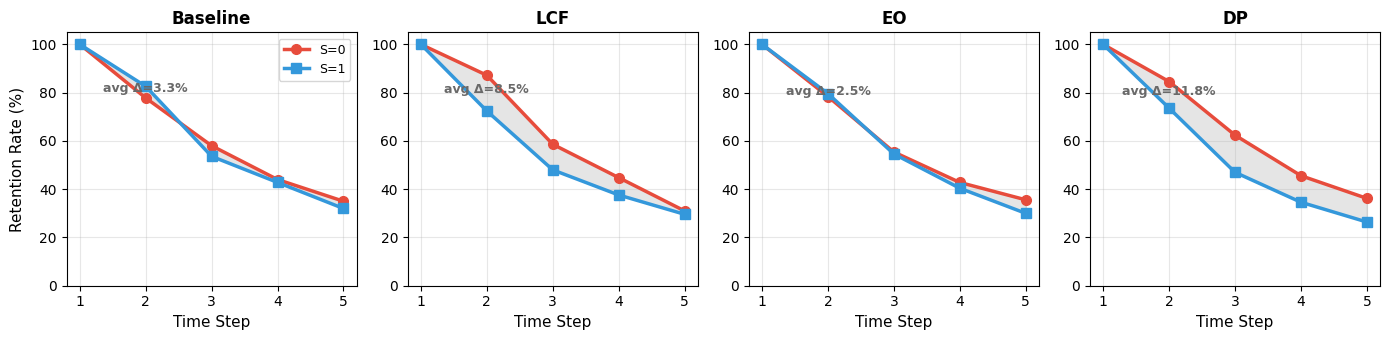

In [143]:
#Figure 1 Retention rates by group (4-panel)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
colors = {'S=0': '#E74C3C', 'S=1': '#3498DB'}

methods = list(results.keys())
for idx, method in enumerate(methods):
    ax = axes[idx]
    ax.plot(steps, results[method]['S=0'], 'o-', color=colors['S=0'], label='S=0', linewidth=2.5, markersize=7)
    ax.plot(steps, results[method]['S=1'], 's-', color=colors['S=1'], label='S=1', linewidth=2.5, markersize=7)
    ax.fill_between(steps, results[method]['S=0'], results[method]['S=1'], alpha=0.2, color='gray')

    #disparity_t2 = results[method]['disparity'][1]
    avg_disparity = np.mean(results[method]['disparity'][1:])   # skip step 1 which is always 0, average for t 2-5
    mid_y = (results[method]['S=0'][1] + results[method]['S=1'][1]) / 2
    ax.annotate(f'avg Δ={avg_disparity:.1f}%', xy=(2, mid_y), fontsize=9, ha='center', color='dimgray', fontweight='bold')

    ax.set_title(method, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.set_xticks(steps)
    ax.set_xlabel('Time Step', fontsize=11)
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.set_ylabel('Retention Rate (%)', fontsize=11)
        ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

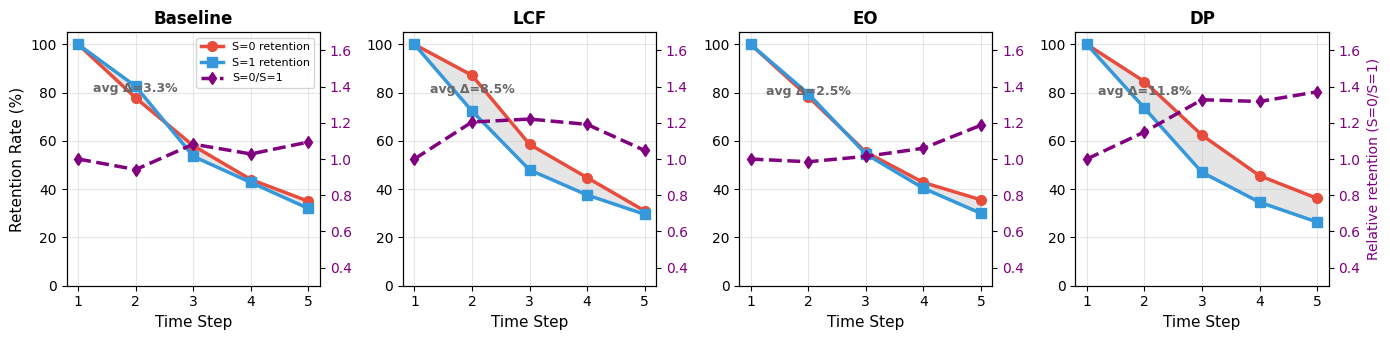

In [144]:
# Figure 2 Retention by group + relative retention ratio (twin axis, 4-panel)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
left_colors = {'S=0': '#E74C3C', 'S=1': '#3498DB'}
ratio_color = 'purple'

for idx, method in enumerate(methods):
    ax = axes[idx]
    ax2 = ax.twinx()

    s0 = np.array(results[method]['S=0'], dtype=float)
    s1 = np.array(results[method]['S=1'], dtype=float)
    ratio = np.divide(s0, s1, out=np.full_like(s0, np.nan), where=(s1 != 0))

    l1, = ax.plot(steps, s0, 'o-', color=left_colors['S=0'], label='S=0 retention', linewidth=2.5, markersize=7)
    l2, = ax.plot(steps, s1, 's-', color=left_colors['S=1'], label='S=1 retention', linewidth=2.5, markersize=7)
    ax.fill_between(steps, s0, s1, alpha=0.2, color='gray')
    l3, = ax2.plot(steps, ratio, 'd--', color=ratio_color, label='S=0/S=1', linewidth=2.5, markersize=6)

    #disparity_t2 = results[method]['disparity'][1]
    avg_disparity = np.mean(results[method]['disparity'][1:])   # skip step 1 which is always 0, average for t 2-5
    mid_y = (s0[1] + s1[1]) / 2
    ax.annotate(f'avg Δ={avg_disparity:.1f}%', xy=(2, mid_y), fontsize=9, ha='center', color='dimgray', fontweight='bold')

    ax.set_title(method, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.set_xticks(steps)
    ax.set_xlabel('Time Step', fontsize=11)
    ax.grid(True, alpha=0.3)

    if idx == len(methods) - 1:
        ax2.set_ylabel('Relative retention (S=0/S=1)', fontsize=10, color=ratio_color)
    ax2.tick_params(axis='y', labelcolor=ratio_color)
    ax2.set_ylim(0.3, 1.7)

    if idx == 0:
        ax.set_ylabel('Retention Rate (%)', fontsize=11)
        ax.legend(handles=[l1, l2, l3], loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

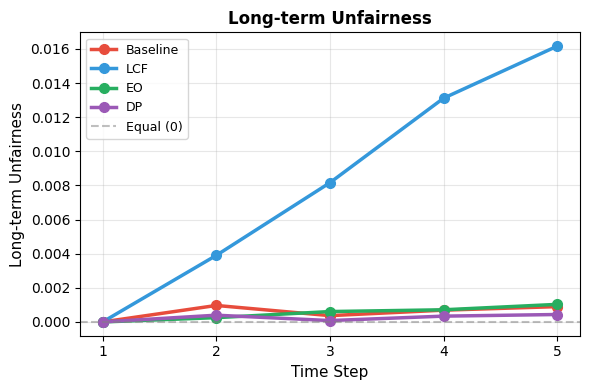

In [145]:
# Figure 3 Merged long-term unfairness (single plot)
method_colors = {'Baseline': '#E74C3C', 'LCF': '#3498DB', 'EO': '#27AE60', 'DP': '#9B59B6'} #, 'PE': '#F39C12' }

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
for method in methods:
    ax.plot(steps, results[method]['unfairness'], 'o-', color=method_colors[method], label=method, linewidth=2.5, markersize=7)

ax.axhline(y=0.0, color='gray', linestyle='--', alpha=0.5, label='Equal (0)')
ax.set_xlabel('Time Step', fontsize=11)
ax.set_ylabel('Long-term Unfairness', fontsize=11)
ax.set_title('Long-term Unfairness', fontsize=12, fontweight='bold')
ax.set_xticks(steps)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('long_term_unfairness_merged.png', dpi=300, bbox_inches='tight')
plt.savefig('long_term_unfairness_merged.pdf', bbox_inches='tight')
plt.show()


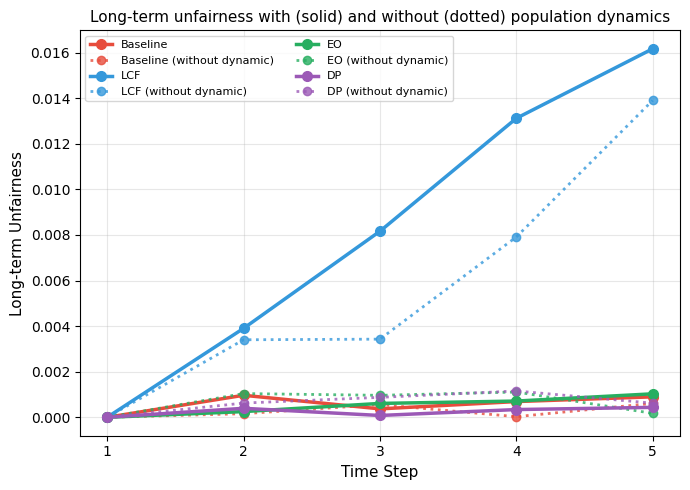

In [146]:
#fig combining with and without population dynamics
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
for method in methods:
    ax.plot(steps, results[method]['unfairness'], 'o-',
            color=method_colors[method], label=method, linewidth=2.5, markersize=7)
    ax.plot(steps, results_no_dynamic[method]['unfairness'], 'o:',
            color=method_colors[method], label=f'{method} (without dynamic)',
            linewidth=2, markersize=6, alpha=0.8)

ax.set_xlabel('Time Step', fontsize=11)
ax.set_ylabel('Long-term Unfairness', fontsize=11)
ax.set_title('Long-term unfairness with (solid) and without (dotted) population dynamics', fontsize=11)
ax.set_xticks(steps)
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dynamic_compare_baf.png', dpi=300, bbox_inches='tight')
plt.show()

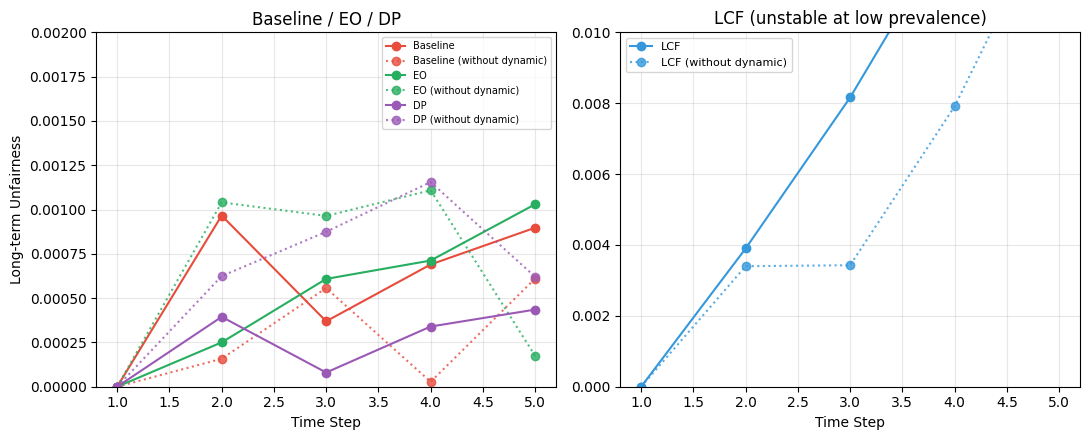

In [160]:
# fig separating LCF from others to avoid stretching y-axis.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: everything except LCF
for method in ['Baseline', 'EO', 'DP']:
    axes[0].plot(steps, results[method]['unfairness'], 'o-', color=method_colors[method], label=method)
    axes[0].plot(steps, results_no_dynamic[method]['unfairness'], 'o:', color=method_colors[method],
                 label=f'{method} (without dynamic)', alpha=0.8)
axes[0].set_title('Baseline / EO / DP'); axes[0].set_xlabel('Time Step'); axes[0].set_ylabel('Long-term Unfairness')
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

# Right: LCF alone, own scale
axes[1].plot(steps, results['LCF']['unfairness'], 'o-', color=method_colors['LCF'], label='LCF')
axes[1].plot(steps, results_no_dynamic['LCF']['unfairness'], 'o:', color=method_colors['LCF'],
             label='LCF (without dynamic)', alpha=0.8)
axes[1].set_title('LCF (unstable at low prevalence)')
axes[1].set_xlabel('Time Step'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

y_max_lcf = 0.01
y_max_others = 0.002
axes[0].set_ylim(0, y_max_others)
axes[1].set_ylim(0, y_max_lcf)

plt.tight_layout()
plt.show()

In [148]:
# Detailed metrics table reuses results_lr/lcf/eo/dp directly,
# NO second run_simulation() call needed (the original notebook's run_and_store() duplicated work that results_lr/lcf/eo/dp already contain).
def compute_detailed_metrics(s, As, Ds, Ys):
    s = np.array(s)
    n_s0_total = np.sum(s == 0)
    n_s1_total = np.sum(s == 1)

    print("Step | N(S=0) | N(S=1) | S=0 Share | Rep. Ratio | H(S=0) | H(S=1) | H.Ratio | Signed Δ(Approval)")
    print("-" * 120)

    metrics = {'s0_share': [], 'rep_ratio': [], 'signed_delta': [], 'retention_s0': [], 'retention_s1': [],
               'disparity': [], 'h_s0': [], 'h_s1': [], 'h_ratio': []}

    prev_active_s0 = prev_active_s1 = None

    for t in range(len(As)):
        A_t = np.array(As[t])
        D_t = np.array(Ds[t])

        active_s0 = np.sum((s == 0) & (A_t == 1))
        active_s1 = np.sum((s == 1) & (A_t == 1))
        total_active = active_s0 + active_s1
        s0_share = active_s0 / total_active if total_active > 0 else 0

        retention_s0 = (active_s0 / n_s0_total) * 100 if n_s0_total > 0 else np.nan
        retention_s1 = (active_s1 / n_s1_total) * 100 if n_s1_total > 0 else np.nan
        disparity = abs(retention_s0 - retention_s1)
        rep_ratio = retention_s0 / retention_s1 if retention_s1 and retention_s1 > 0 else np.nan

        if t == 0:
            h_s0 = h_s1 = 1.0
        else:
            h_s0 = (active_s0 / prev_active_s0) if (prev_active_s0 is not None and prev_active_s0 > 0) else np.nan
            h_s1 = (active_s1 / prev_active_s1) if (prev_active_s1 is not None and prev_active_s1 > 0) else np.nan
        h_ratio = (h_s0 / h_s1) if (h_s1 is not None and not np.isnan(h_s1) and h_s1 != 0) else np.nan

        prev_active_s0, prev_active_s1 = active_s0, active_s1

        active_mask = A_t == 1
        if active_s0 > 0 and active_s1 > 0:
            approval_s0 = np.mean(D_t[(s == 0) & active_mask])
            approval_s1 = np.mean(D_t[(s == 1) & active_mask])
            signed_delta = approval_s0 - approval_s1
        else:
            signed_delta = np.nan

        for k, v in zip(['s0_share','rep_ratio','signed_delta','retention_s0','retention_s1','disparity','h_s0','h_s1','h_ratio'],
                         [s0_share, rep_ratio, signed_delta, retention_s0, retention_s1, disparity, h_s0, h_s1, h_ratio]):
            metrics[k].append(v)

        print(f"  {t+1}  |  {active_s0:4d}  |  {active_s1:4d}  |   {s0_share:.2f}    |    {rep_ratio:6.2f}  |"
              f"  {h_s0:5.2f}  |  {h_s1:5.2f}  |  {h_ratio:6.2f}  |      {signed_delta:+.3f}")

    return metrics


print("\n=== Baseline ===")
metrics_baseline = compute_detailed_metrics(results_lr[0], results_lr[4], results_lr[3], results_lr[2])
print("\n=== LCF ===")
metrics_LCF = compute_detailed_metrics(results_lcf[0], results_lcf[4], results_lcf[3], results_lcf[2])
print("\n=== EO ===")
metrics_eo = compute_detailed_metrics(results_eo[0], results_eo[4], results_eo[3], results_eo[2])
print("\n=== DP ===")
metrics_dp = compute_detailed_metrics(results_dp[0], results_dp[4], results_dp[3], results_dp[2])
#print("\n=== PE ===")
#metrics_pe = compute_detailed_metrics(results_pe[0], results_pe[4], results_pe[3], results_pe[2])

all_metrics = {'Baseline': metrics_baseline, 'LCF': metrics_LCF, 'EO': metrics_eo, 'DP': metrics_dp} # 'PE': metrics_pe}


=== Baseline ===
Step | N(S=0) | N(S=1) | S=0 Share | Rep. Ratio | H(S=0) | H(S=1) | H.Ratio | Signed Δ(Approval)
------------------------------------------------------------------------------------------------------------------------
  1  |   500  |   500  |   0.50    |      1.00  |   1.00  |   1.00  |    1.00  |      -0.042
  2  |   389  |   413  |   0.49    |      0.94  |   0.78  |   0.83  |    0.94  |      +0.092
  3  |   290  |   268  |   0.52    |      1.08  |   0.75  |   0.65  |    1.15  |      -0.027
  4  |   220  |   214  |   0.51    |      1.03  |   0.76  |   0.80  |    0.95  |      +0.101
  5  |   175  |   160  |   0.52    |      1.09  |   0.80  |   0.75  |    1.06  |      +0.019

=== LCF ===
Step | N(S=0) | N(S=1) | S=0 Share | Rep. Ratio | H(S=0) | H(S=1) | H.Ratio | Signed Δ(Approval)
------------------------------------------------------------------------------------------------------------------------
  1  |   500  |   500  |   0.50    |      1.00  |   1.00  |   1.00  

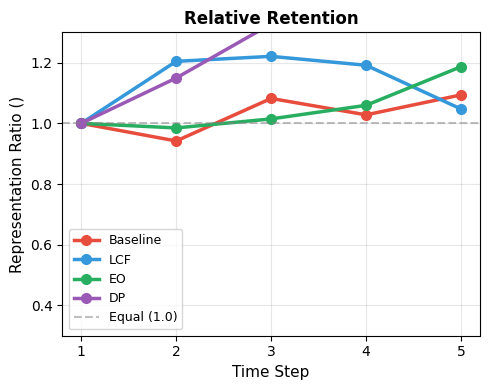

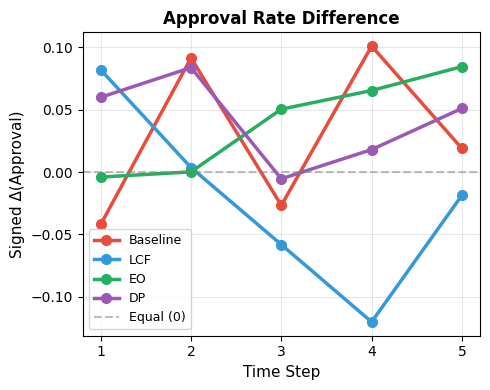

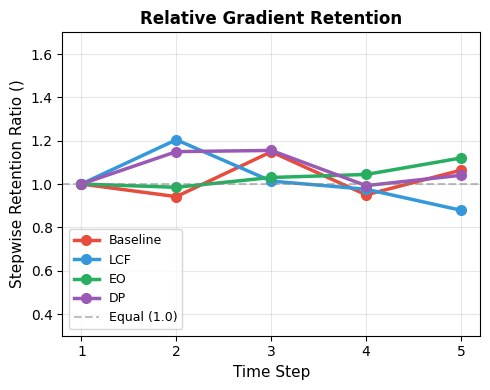

In [149]:
# Figures 4-6 -- H-linecharts (rep_ratio, signed_delta, h_ratio)
single_figsize = (5, 4)

fig, ax = plt.subplots(1, 1, figsize=single_figsize)
for method in methods:
    ax.plot(steps, all_metrics[method]['rep_ratio'], 'o-', color=method_colors[method], label=method, linewidth=2.5, markersize=7)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Equal (1.0)')
ax.set_xlabel('Time Step', fontsize=11); ax.set_ylabel('Representation Ratio ()', fontsize=11)
ax.set_title('Relative Retention', fontsize=12, fontweight='bold')
ax.set_ylim(0.3, 1.3); ax.set_xticks(steps); ax.legend(loc='lower left', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('relative_retention.png', dpi=300, bbox_inches='tight'); plt.savefig('relative_retention.pdf', bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(1, 1, figsize=single_figsize)
for method in methods:
    ax.plot(steps, all_metrics[method]['signed_delta'], 'o-', color=method_colors[method], label=method, linewidth=2.5, markersize=7)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Equal (0)')
ax.set_xlabel('Time Step', fontsize=11); ax.set_ylabel('Signed Δ(Approval)', fontsize=11)
ax.set_title('Approval Rate Difference', fontsize=12, fontweight='bold')
ax.set_xticks(steps); ax.legend(loc='lower left', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('approval_rate_difference.png', dpi=300, bbox_inches='tight'); plt.savefig('approval_rate_difference.pdf', bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(1, 1, figsize=single_figsize)
for method in methods:
    ax.plot(steps, all_metrics[method]['h_ratio'], 'o-', color=method_colors[method], label=method, linewidth=2.5, markersize=7)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Equal (1.0)')
ax.set_xlabel('Time Step', fontsize=11); ax.set_ylabel('Stepwise Retention Ratio ()', fontsize=11)
ax.set_title('Relative Gradient Retention', fontsize=12, fontweight='bold')
ax.set_xticks(steps); ax.set_ylim(0.3, 1.7); ax.legend(loc='lower left', fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('relative_gradient_retention.png', dpi=300, bbox_inches='tight'); plt.savefig('relative_gradient_retention.pdf', bbox_inches='tight'); plt.show()

In [150]:
print("EO w:", eo_model.w.value[:5])
#print("PE w:", pe_model.w.value[:5])
#print("Max abs diff:", np.abs(eo_model.w.value - pe_model.w.value).max())

EO w: [-0.02596901 -0.08711242 -0.00860543  0.5972888 ]


# Run simulation no dynamic to check for population dynamic

In [151]:
def run_no_dynamic_seeded(model, model_name, bank, agent, steps=5, run_seed=2026):
    np.random.seed(run_seed)
    s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_no_dynamic(
        decision_model=model,
        repayment_model=bank,
        agent=agent,
        steps=steps,
        enforce_demographic_mixing=True,
        k_same=8,
        k_other=2,
        directed=False,
        graph_seed=run_seed,
        seed=run_seed,
        decision_coef=0.8,
        repayment_coef=0.8,
    )
    return s, Xs, Ys, Ds, As


def run_multiseed_no_dynamic(model, model_name, bank, agent, steps=5, seeds=(2026, 7, 13, 42, 99)):
    disparities = []
    for sd in seeds:
        s, Xs, Ys, Ds, As = run_no_dynamic_seeded(model, model_name, bank, agent, steps, sd)
        s_arr = np.array(s)
        D_final = np.array(Ds[-1])
        approval_s0 = D_final[s_arr == 0].mean() * 100
        approval_s1 = D_final[s_arr == 1].mean() * 100
        disparities.append(abs(approval_s0 - approval_s1))
    return np.mean(disparities), np.std(disparities), disparities

In [152]:
for name, model in [('Baseline', lr), ('LCF', LCF), ('EO', eo_model), ('DP', dp_model)]:
    mean_d, std_d, all_d = run_multiseed_no_dynamic(model, name, bank, agent_test)
    print(f"{name} (no dynamic): {mean_d:.1f}% ± {std_d:.1f}%  (runs: {[round(x,1) for x in all_d]})")

Baseline (no dynamic): 5.3% ± 3.9%  (runs: [np.float64(2.4), np.float64(8.2), np.float64(11.4), np.float64(1.2), np.float64(3.4)])
LCF (no dynamic): 3.3% ± 3.2%  (runs: [np.float64(0.8), np.float64(5.2), np.float64(8.6), np.float64(0.6), np.float64(1.2)])
EO (no dynamic): 3.5% ± 3.8%  (runs: [np.float64(1.0), np.float64(6.8), np.float64(9.2), np.float64(0.4), np.float64(0.0)])
DP (no dynamic): 5.4% ± 3.9%  (runs: [np.float64(2.4), np.float64(8.4), np.float64(11.4), np.float64(1.2), np.float64(3.4)])


In [153]:
print("Baseline weights:", lr.params)
print("EO weights:", eo_model.params)

Baseline weights: [-0.12026393 -0.08931355 -0.00895635  0.6588676 ]
EO weights: [-0.02596901 -0.08711242 -0.00860543  0.5972888 ]


# Unfairness multiseed

In [154]:
def unfairness_multiseed(model, bank, agent, dynamic=True, seeds=(2026, 7, 13, 42, 99)):
    finals = []
    for sd in seeds:
        np.random.seed(sd)
        if dynamic:
            s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_resynced(
                model, agent, 5, repayment_model=bank, graph_seed=sd, seed=sd)
        else:
            s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_no_dynamic(
                model, agent, 5, repayment_model=bank, graph_seed=sd, seed=sd)
        m = extract_metrics((s, Xs, Ys, Ds, As), model)
        finals.append(m['unfairness'][-1])
    return np.mean(finals), np.std(finals), finals


for name, model in [('Baseline', lr), ('EO', eo_model), ('DP', dp_model), ('LCF', LCF)]:
    m_with, s_with, _ = unfairness_multiseed(model, bank, agent_test, dynamic=True)
    m_without, s_without, _ = unfairness_multiseed(model, bank, agent_test, dynamic=False)
    print(f"{name}: with={m_with:.3f}±{s_with:.3f}  without={m_without:.3f}±{s_without:.3f}  ratio={m_without/m_with:.1f}x")

Baseline: with=0.001±0.000  without=0.001±0.001  ratio=2.8x
EO: with=0.000±0.000  without=0.001±0.001  ratio=2.9x
DP: with=0.001±0.000  without=0.001±0.001  ratio=2.9x
LCF: with=0.012±0.002  without=0.017±0.002  ratio=1.5x


In [155]:
from scipy import stats

def unfairness_multiseed_with_pvalue(model, bank, agent, seeds=(2026, 7, 13, 42, 99)):
    with_vals, without_vals = [], []
    for sd in seeds:
        np.random.seed(sd)
        s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_resynced(
            model, agent, 5, repayment_model=bank, graph_seed=sd, seed=sd)
        with_vals.append(extract_metrics((s, Xs, Ys, Ds, As), model)['unfairness'][-1])

        np.random.seed(sd)
        s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_no_dynamic(
            model, agent, 5, repayment_model=bank, graph_seed=sd, seed=sd)
        without_vals.append(extract_metrics((s, Xs, Ys, Ds, As), model)['unfairness'][-1])

    t_stat, p_val = stats.ttest_rel(without_vals, with_vals)
    return {
        'with_mean': np.mean(with_vals), 'with_std': np.std(with_vals),
        'without_mean': np.mean(without_vals), 'without_std': np.std(without_vals),
        'ratio': np.mean(without_vals) / np.mean(with_vals),
        'p_value': p_val,
    }


for name, model in [('Baseline', lr), ('EO', eo_model), ('DP', dp_model), ('LCF', LCF)]:
    r = unfairness_multiseed_with_pvalue(model, bank, agent_test)
    sig = '*' if r['p_value'] < 0.05 else 'n.s.'
    print(f"{name}: with={r['with_mean']:.3f}±{r['with_std']:.3f}  without={r['without_mean']:.3f}±{r['without_std']:.3f}  "
          f"ratio={r['ratio']:.1f}x  p={r['p_value']:.3f} ({sig})")

Baseline: with=0.001±0.000  without=0.001±0.001  ratio=2.8x  p=0.028 (*)
EO: with=0.000±0.000  without=0.001±0.001  ratio=2.9x  p=0.028 (*)
DP: with=0.001±0.000  without=0.001±0.001  ratio=2.9x  p=0.011 (*)
LCF: with=0.012±0.002  without=0.017±0.002  ratio=1.5x  p=0.003 (*)


In [156]:
def avg_disparity_seeded(model, bank, agent, seeds=(2026, 7, 13, 42, 99)):
    avg_disparities = []
    for sd in seeds:
        np.random.seed(sd)
        s, adj, edges, Xs, Ys, Ds, Ps, Os, Us, As = run_simulation_resynced(
            model, agent, 5, repayment_model=bank, graph_seed=sd, seed=sd)
        s_arr = np.array(s)
        step_disparities = []
        for A_t in As:
            A_t = np.array(A_t)
            r0 = A_t[s_arr == 0].mean() * 100
            r1 = A_t[s_arr == 1].mean() * 100
            step_disparities.append(abs(r0 - r1))
        avg_disparities.append(np.mean(step_disparities[1:]))  # skip step 1, always 0
    return np.mean(avg_disparities), np.std(avg_disparities), avg_disparities


for name, model in [('Baseline', lr), ('LCF', LCF), ('EO', eo_model), ('DP', dp_model)]:
    mean_d, std_d, all_d = avg_disparity_seeded(model, bank, agent_test)
    print(f"{name}: avg_disparity={mean_d:.1f}±{std_d:.1f}  (runs: {[round(x,1) for x in all_d]})")

Baseline: avg_disparity=8.6±2.4  (runs: [np.float64(9.6), np.float64(7.7), np.float64(12.9), np.float64(6.3), np.float64(6.7)])
LCF: avg_disparity=3.4±1.6  (runs: [np.float64(2.0), np.float64(4.3), np.float64(5.9), np.float64(1.5), np.float64(3.0)])
EO: avg_disparity=5.3±2.1  (runs: [np.float64(4.4), np.float64(5.5), np.float64(9.2), np.float64(4.2), np.float64(3.0)])
DP: avg_disparity=8.6±2.4  (runs: [np.float64(9.6), np.float64(7.7), np.float64(12.9), np.float64(6.3), np.float64(6.7)])


In [157]:
print("Baseline:", lr.params)
print("EO:", eo_model.params)
print("DP:", dp_model.params)

Baseline: [-0.12026393 -0.08931355 -0.00895635  0.6588676 ]
EO: [-0.02596901 -0.08711242 -0.00860543  0.5972888 ]
DP: [-0.12062331 -0.08890973 -0.0092524   0.65874316]


In [158]:
# does the training bootstrap's data ALREADY satisfy DP's fairness criterion,
# before any constrained optimization happens?
from sklearn.linear_model import LogisticRegression
unconstrained = LogisticRegression().fit(X_comb, s_comb)  # or however lr is trained here
# check DP gap directly: approval rate difference between groups, on training data
_, p = lr.predict(s_comb, X_comb)
approve = (p >= 0.5).astype(int)
print("Approval rate S=0:", approve[s_comb==0].mean())
print("Approval rate S=1:", approve[s_comb==1].mean())

Approval rate S=0: 1.0
Approval rate S=1: 1.0
